# Data Science Workflow: AAPL Stock Price Prediction
This notebook demonstrates an advanced Data Science Workflow predicting AAPL stock prices using multivariate time-series data with Bidirectional LSTM and GRU, predicting explicitly based on Percentage Returns to enforce stationarity.

## 1. Setup & Imports

In [8]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, accuracy_score, precision_score, recall_score, f1_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')

# Set aesthetic styling
sns.set_style('whitegrid')

## 2. Acquire Data
We download technical and historical AAPL data.

In [9]:
ticker = 'AAPL'
data = yf.download(ticker, start='2015-01-01', end='2024-01-01')

# Flatten MultiIndex columns if present (yfinance sometimes returns this)
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(1)

df = data[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Open,High,Low,Close,Volume
Date,,,,,
2015-01-02,24.671155,24.682230,23.776357,24.214897,212818400
2015-01-05,23.984553,24.064287,23.346678,23.532724,257142000
2015-01-06,23.596950,23.794071,23.173914,23.534935,263188400
2015-01-07,23.743125,23.964610,23.632383,23.864943,160423600
2015-01-08,24.192739,24.839473,24.075351,24.781887,237458000


## 3. Exploratory Data Analysis (EDA)
Visualizing the historical price trends, volume distributions, and inter-feature correlations.

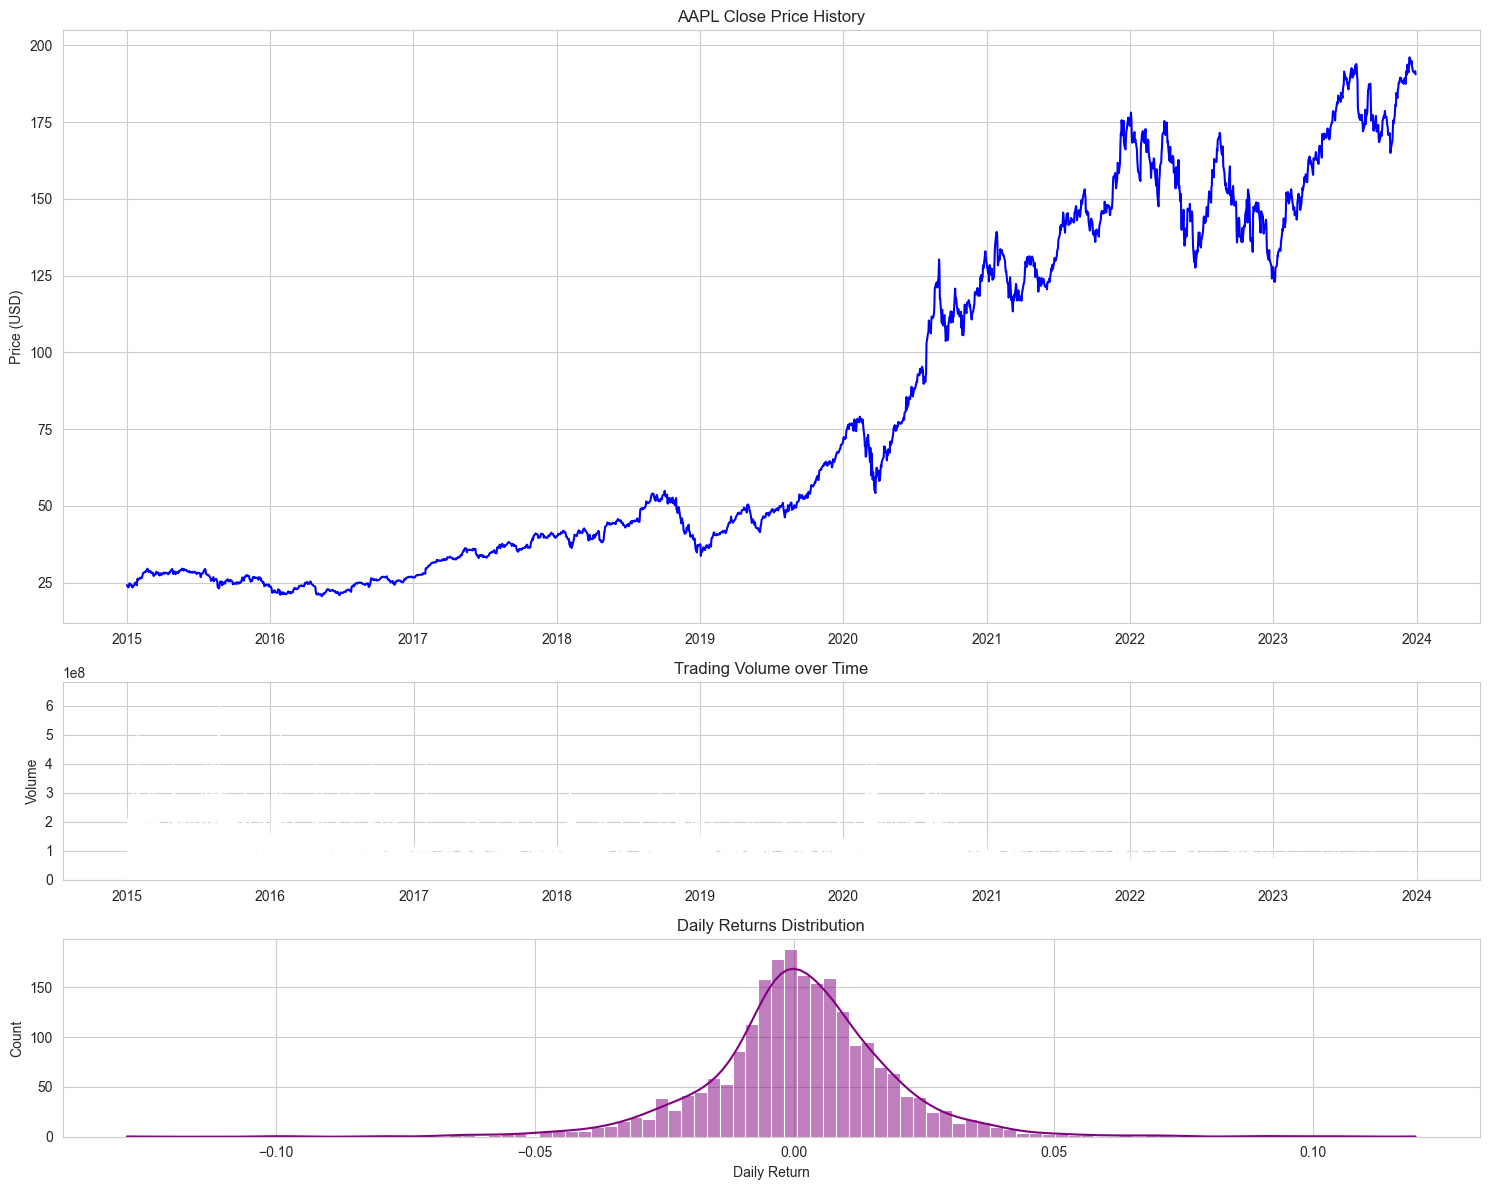

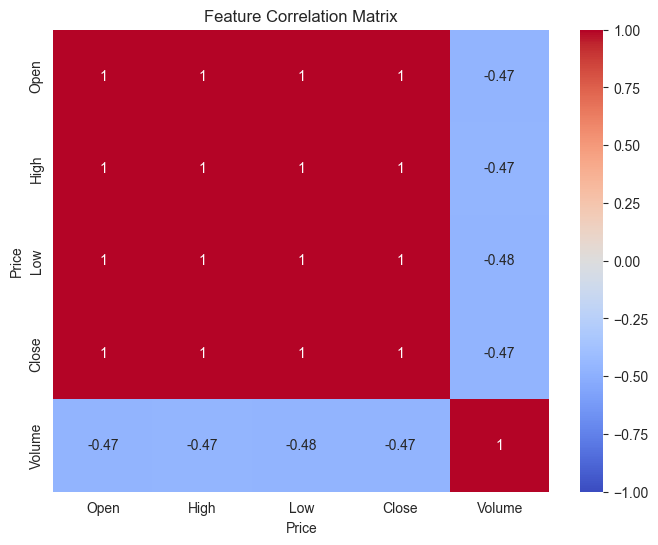

In [10]:
fig, ax = plt.subplots(3, 1, figsize=(15, 12), gridspec_kw={'height_ratios': [3, 1, 1]})

# 1. Price
ax[0].plot(df.index, df['Close'], c='blue')
ax[0].set_title('AAPL Close Price History')
ax[0].set_ylabel('Price (USD)')

# 2. Volume
ax[1].bar(df.index, df['Volume'], color='gray')
ax[1].set_title('Trading Volume over Time')
ax[1].set_ylabel('Volume')

# 3. Daily Returns
daily_returns = df['Close'].pct_change()
sns.histplot(daily_returns.dropna(), bins=100, kde=True, ax=ax[2], color='purple')
ax[2].set_title('Daily Returns Distribution')
ax[2].set_xlabel('Daily Return')

plt.tight_layout()
plt.show()

# 4. Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix')
plt.show()


## 4. Feature Engineering
Engineering technical indicators: SMA (20, 50), MACD, and RSI to enrich our dataset.
Crucially, we define `Return` (Percentage Change) as the main Target Variable to enforce stationarity and improve directional learning.

In [11]:
# Moving Averages
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()

# MACD
exp1 = df['Close'].ewm(span=12, adjust=False).mean()
exp2 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = exp1 - exp2
df['Signal_Line'] = df['MACD'].ewm(span=9, adjust=False).mean()

# RSI
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

# Calculate Target Variable: Percentage Return
df['Return'] = df['Close'].pct_change()

# Drop NaN values generated by rolling windows and differencing
df.dropna(inplace=True)

df.tail()

Price,Open,High,Low,Close,Volume,SMA_20,SMA_50,MACD,Signal_Line,RSI,Return
Date,,,,,,,,,,,
2023-12-22,193.173208,193.400854,190.985939,191.609467,37149600,191.677263,183.401247,2.630682,3.232233,59.246145,-0.005548
2023-12-26,191.619334,191.896454,190.847355,191.065094,28919300,191.838587,183.686984,2.302596,3.046306,49.031841,-0.002841
2023-12-27,190.510906,191.510516,189.125291,191.164108,48087700,191.974675,183.977272,2.027207,2.842486,52.291561,0.000518
2023-12-28,192.143916,192.658574,191.183888,191.589676,34049900,192.183011,184.307107,1.822293,2.638447,47.920485,0.002226
2023-12-29,191.906355,192.401214,189.758668,190.550446,42672100,192.310684,184.642054,1.558079,2.422374,40.185121,-0.005424


## 5. Data Preprocessing
Normalizing the multi-variate dataset and grouping it into sequences.

In [12]:
# Features vs. Target (Target is 'Return')
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'SMA_20', 'SMA_50', 'MACD', 'Signal_Line', 'RSI', 'Return']

# Scale the data using MinMaxScaler
scaler_features = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler_features.fit_transform(df[features].values)

# Scaler for target variable 'Return'
scaler_target = MinMaxScaler(feature_range=(0, 1))
scaled_target = scaler_target.fit_transform(df[['Return']].values)

lookback = 60

X, y = [], []
for i in range(lookback, len(scaled_data)):
    X.append(scaled_data[i-lookback:i, :])
    y.append(scaled_target[i, 0])

X, y = np.array(X), np.array(y)

# Train-Test Split (80% train, 20% test chronologically)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Store unscaled absolute prices array to reconstruct predicted absolute prices later
# We need Price(t-1) to calculate Price(t).
# actual_prices_test represents Price(t) for the test set.
# prev_prices_test represents Price(t-1) for the test set.
actual_prices_test = df['Close'].values[lookback+split:]
prev_prices_test = df['Close'].values[lookback+split-1:-1]
actual_returns_test = df['Return'].values[lookback+split:]

print(f"X_train shape: {X_train.shape} (samples, lookback, features)")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")


X_train shape: (1724, 60, 11) (samples, lookback, features)
X_test shape: (431, 60, 11)
y_train shape: (1724,)


## 6. Model Data: Build, Train, Predict
Using enhanced Bidirectional LSTM and GRU, funneled architecture, alongside callbacks to stop early and improve optimization.

In [13]:
# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)
callbacks = [early_stopping, reduce_lr]

# --- LSTM (Bidirectional & Funnel) ---
model_lstm = Sequential()
model_lstm.add(Bidirectional(LSTM(units=64, return_sequences=True), input_shape=(X_train.shape[1], X_train.shape[2])))
model_lstm.add(Dropout(0.2))
model_lstm.add(LSTM(units=32, return_sequences=False))
model_lstm.add(Dropout(0.2))
model_lstm.add(Dense(units=1))

optimizer_adam = Adam(learning_rate=0.001)
model_lstm.compile(optimizer=optimizer_adam, loss='mean_squared_error')
print("LSTM Summary:")
model_lstm.summary()

# --- GRU (Bidirectional & Funnel) ---
model_gru = Sequential()
model_gru.add(Bidirectional(GRU(units=64, return_sequences=True), input_shape=(X_train.shape[1], X_train.shape[2])))
model_gru.add(Dropout(0.2))
model_gru.add(GRU(units=32, return_sequences=False))
model_gru.add(Dropout(0.2))
model_gru.add(Dense(units=1))

model_gru.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
print("\nGRU Summary:")
model_gru.summary()

# --- Training (using validation split) ---
print("\nTraining LSTM...")
history_lstm = model_lstm.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1, verbose=1, callbacks=callbacks)

print("\nTraining GRU...")
history_gru = model_gru.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1, verbose=1, callbacks=callbacks)


LSTM Summary:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 60, 128)        │        38,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,553 (232.63 KB)

 Trainable params: 59,553 (232.63 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional) │ (None, 60, 128)        │        29,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 32)             │        15,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,153 (176.38 KB)

 Trainable params: 45,153 (176.38 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM...
Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.0454 - val_loss: 0.0060 - learning_rate: 0.0010
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0101 - val_loss: 0.0053 - learning_rate: 0.0010
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0085 - val_loss: 0.0048 - learning_rate: 0.0010
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0087 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0092 - val_loss: 0.0068 - learning_rate: 0.0010
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0090 - val_loss: 0.0049 - learning_rate: 0.0010
Epoch 7/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0089 - val_loss: 0.0043 - learning_rate: 0.0010
Epoch 8/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0093 - val_loss: 0.0043 - learning_rate: 0.0010
Epoch 9/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0082 - val_loss: 0.0048 - learning_rate:

## 7. Model Evaluation & Visualization
Reverting model outputs to absolute closing prices to compare and score performances accurately.

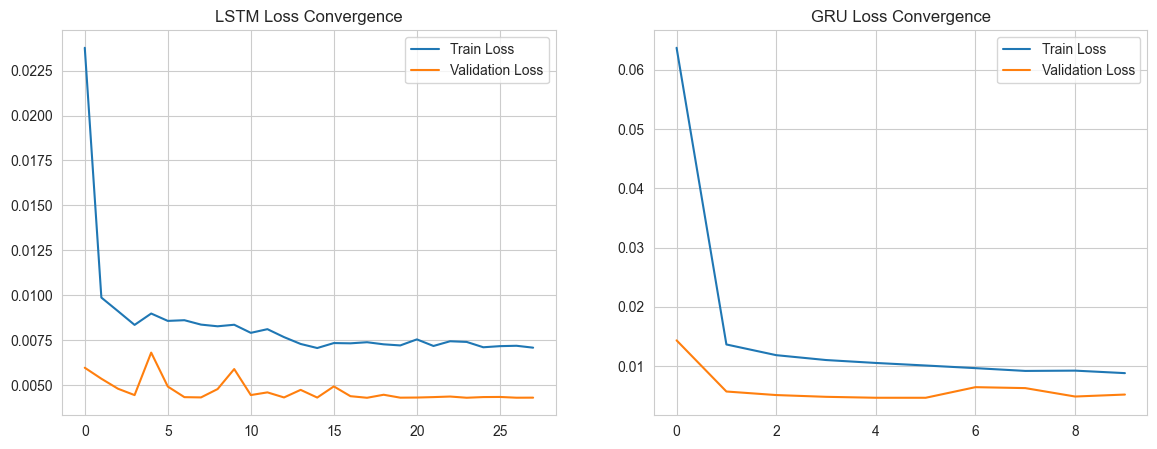

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step


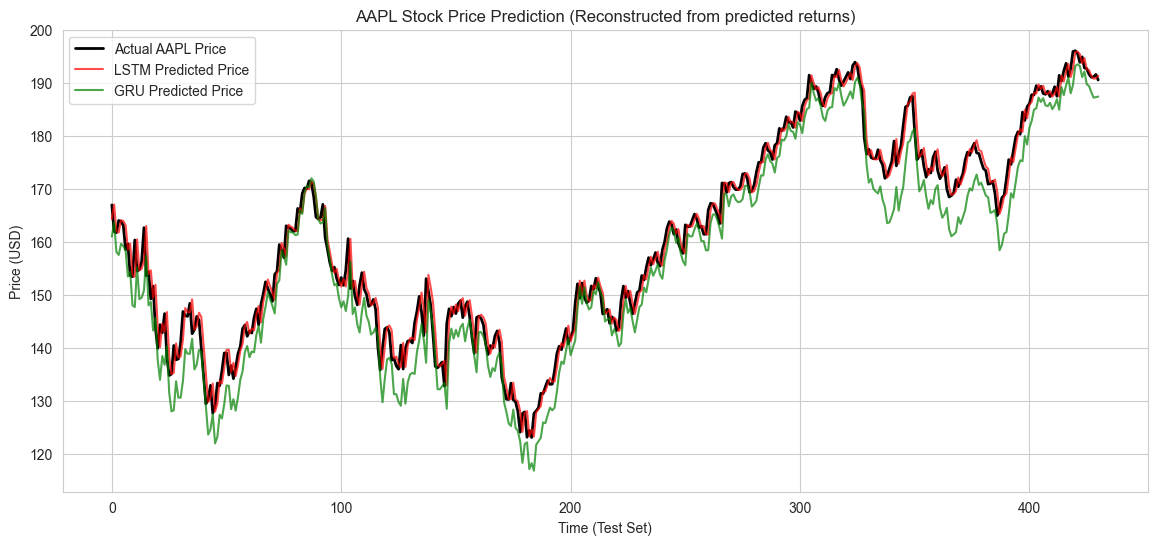

LSTM Absolute RMSE: 2.78
GRU Absolute RMSE:  5.33

[LSTM] Directional Metrics (Returns):
Accuracy: 50.35% | Precision: 51.85% | Recall: 74.34% | F1: 61.09%

[GRU] Directional Metrics (Returns):
Accuracy: 47.33% | Precision: 40.00% | Recall: 0.88% | F1: 1.73%


In [14]:
# Plot Training & Validation Loss
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# LSTM Loss
ax[0].plot(history_lstm.history['loss'], label='Train Loss')
ax[0].plot(history_lstm.history['val_loss'], label='Validation Loss')
ax[0].set_title('LSTM Loss Convergence')
ax[0].legend()

# GRU Loss
ax[1].plot(history_gru.history['loss'], label='Train Loss')
ax[1].plot(history_gru.history['val_loss'], label='Validation Loss')
ax[1].set_title('GRU Loss Convergence')
ax[1].legend()

plt.show()

# Predictions (these are scaled RETURNS)
pred_lstm_scaled_ret = model_lstm.predict(X_test)
pred_gru_scaled_ret = model_gru.predict(X_test)

# Inverse transform to get actual Returns
pred_lstm_ret = scaler_target.inverse_transform(pred_lstm_scaled_ret).flatten()
pred_gru_ret = scaler_target.inverse_transform(pred_gru_scaled_ret).flatten()
y_test_ret = scaler_target.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Reconstruct Absolute Prices from Returns
# Price(t) = Price(t-1) * (1 + Return(t))
pred_lstm_price = prev_prices_test * (1 + pred_lstm_ret)
pred_gru_price = prev_prices_test * (1 + pred_gru_ret)

# Visualization
plt.figure(figsize=(14,6))
plt.plot(actual_prices_test, color='black', label='Actual AAPL Price', linewidth=2)
plt.plot(pred_lstm_price, color='red', label='LSTM Predicted Price', alpha=0.7)
plt.plot(pred_gru_price, color='green', label='GRU Predicted Price', alpha=0.7)
plt.title('AAPL Stock Price Prediction (Reconstructed from predicted returns)')
plt.xlabel('Time (Test Set)')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

# Quantitative Metrics on Reconstructed Prices
rmse_lstm = np.sqrt(mean_squared_error(actual_prices_test, pred_lstm_price))
rmse_gru = np.sqrt(mean_squared_error(actual_prices_test, pred_gru_price))

print(f"LSTM Absolute RMSE: {rmse_lstm:.2f}")
print(f"GRU Absolute RMSE:  {rmse_gru:.2f}")

# Directional Accuracy Metrics (based on whether the predicted return correctly guessed the sign of the actual return)
actual_direction = (y_test_ret > 0).astype(int)
pred_direction_lstm = (pred_lstm_ret > 0).astype(int)
pred_direction_gru = (pred_gru_ret > 0).astype(int)

def print_metrics(model_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    print(f"\n[{model_name}] Directional Metrics (Returns):")
    print(f"Accuracy: {acc*100:.2f}% | Precision: {prec*100:.2f}% | Recall: {rec*100:.2f}% | F1: {f1*100:.2f}%")

print_metrics("LSTM", actual_direction, pred_direction_lstm)
print_metrics("GRU", actual_direction, pred_direction_gru)
